# Notebook 01 - Yelp Open Dataset EDA

We created this EDA notebook to inspect the Yelp Open Dataset that we intend to work with for building our recommender system. We were particularly focused on the business, user, and reviews JSON datasets, as we have identified them as the most relevant pieces of data we need for building the systems we would like to make (SVD matrix fac, two-towers, etc). 

We inspected some rows of our data to ensure they were loaded before creating distributions and summary statistics to understand the nature of our data. We also ran k-core statistics to help determine which k-core value to use in downstream preprocessing, and we looked at null rates and distributions of columns that could potentially serve as features for a two-towers approach. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import json

## Business

In [2]:
# Load and print total number of business, inspect dataframe head
yelp_business_data_path = "../Yelp JSON/yelp_dataset/yelp_academic_dataset_business.json"

with open(yelp_business_data_path, "r") as f:
    yelp_businesses = [json.loads(line) for line in f]

yelp_business_df = pd.DataFrame(yelp_businesses)
print(f"Total businesses: {len(yelp_business_df):,}")
yelp_business_df.head()

Total businesses: 150,346


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,Pns2l4eNsfO8kk83dixA6A,"Abby Rappoport, LAC, CMQ","1616 Chapala St, Ste 2",Santa Barbara,CA,93101,34.426679,-119.711197,5.0,7,0,{'ByAppointmentOnly': 'True'},"Doctors, Traditional Chinese Medicine, Naturop...",None
1,mpf3x-BjTdTEA3yCZrAYPw,The UPS Store,87 Grasso Plaza Shopping Center,Affton,MO,63123,38.551126,-90.335695,3.0,15,1,{'BusinessAcceptsCreditCards': 'True'},"Shipping Centers, Local Services, Notaries, Ma...","{'Monday': '0:0-0:0', 'Tuesday': '8:0-18:30', ..."
2,tUFrWirKiKi_TAnsVWINQQ,Target,5255 E Broadway Blvd,Tucson,AZ,85711,32.223236,-110.880452,3.5,22,0,"{'BikeParking': 'True', 'BusinessAcceptsCredit...","Department Stores, Shopping, Fashion, Home & G...","{'Monday': '8:0-22:0', 'Tuesday': '8:0-22:0', ..."
3,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'OutdoorSeati...","Restaurants, Food, Bubble Tea, Coffee & Tea, B...","{'Monday': '7:0-20:0', 'Tuesday': '7:0-20:0', ..."
4,mWMc6_wTdE0EUBKIGXDVfA,Perkiomen Valley Brewery,101 Walnut St,Green Lane,PA,18054,40.338183,-75.471659,4.5,13,1,"{'BusinessAcceptsCreditCards': 'True', 'Wheelc...","Brewpubs, Breweries, Food","{'Wednesday': '14:0-22:0', 'Thursday': '16:0-2..."


In [4]:
# Filter Business dataframe by categories - specifically checking restaurant, food strings. 
# Also print open and closed restaurants
mask = yelp_business_df["categories"].str.contains("Restaurants|Food", na=False)
yelp_restaurants_df = yelp_business_df[mask].copy()
print(f"Restaurant/Food businesses: {len(yelp_restaurants_df):,}")
print(f"  of which open:   {yelp_restaurants_df['is_open'].sum():,}")
print(f"  of which closed: {(yelp_restaurants_df['is_open'] == 0).sum():,}")

Restaurant/Food businesses: 64,616
  of which open:   44,582
  of which closed: 20,034


In [5]:
# Review count distribution across restaurants
yelp_restaurants_df["review_count"].describe()

count    64616.000000
mean        76.614089
std        173.383983
min          5.000000
25%         12.000000
50%         28.000000
75%         75.000000
max       7568.000000
Name: review_count, dtype: float64

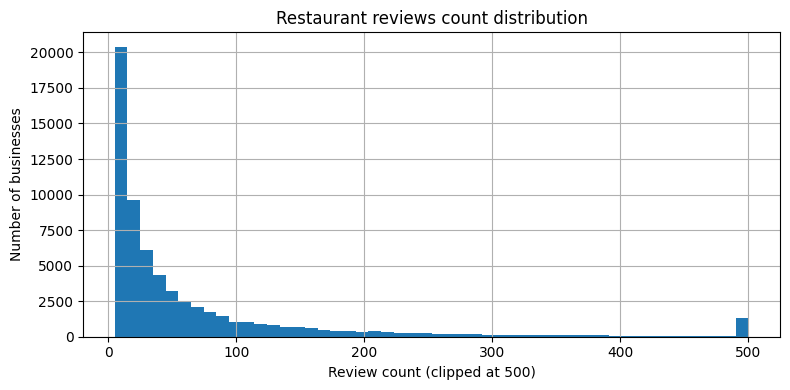

In [6]:
# Create distribution from counts of restaurant reviews
fig, ax = plt.subplots(figsize=(8, 4))
yelp_restaurants_df["review_count"].clip(upper=500).hist(bins=50, ax=ax)
ax.set_xlabel("Review count (clipped at 500)")
ax.set_ylabel("Number of businesses")
ax.set_title("Restaurant reviews count distribution")
plt.tight_layout()
plt.show()

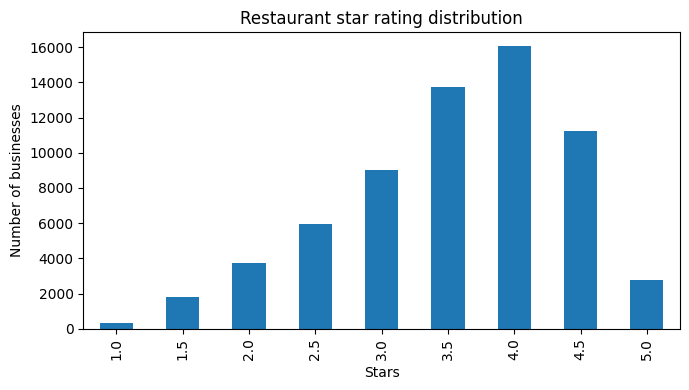

In [7]:
# Distribution of star ratings for restaurants
yelp_restaurants_df["stars"].value_counts().sort_index().plot(kind="bar", figsize=(7, 4))
plt.xlabel("Stars")
plt.ylabel("Number of businesses")
plt.title("Restaurant star rating distribution")
plt.tight_layout()
plt.show()

In [8]:
# Attribute sparsity, completeness of business attributes
attr_series = yelp_restaurants_df["attributes"].dropna().apply(lambda x: list(x.keys()) if isinstance(x, dict) else [])
from collections import Counter
attr_counts = Counter(key for keys in attr_series for key in keys)
attr_df = pd.DataFrame(attr_counts.items(), columns=["attribute", "count"]).sort_values("count", ascending=False)
attr_df["pct_of_restaurants"] = (attr_df["count"] / len(yelp_restaurants_df) * 100).round(1)
attr_df.head(20)

,attribute,count,pct_of_restaurants
6,RestaurantsTakeOut,57816,89.5
3,BusinessParking,56465,87.4
2,BusinessAcceptsCreditCards,56166,86.9
5,RestaurantsPriceRange2,54604,84.5
0,RestaurantsDelivery,53775,83.2
1,OutdoorSeating,46134,71.4
4,BikeParking,44291,68.5
14,RestaurantsReservations,43577,67.4
20,HasTV,42426,65.7
12,GoodForKids,42028,65.0


## Reviews

In [9]:
# Load reviews data
yelp_reviews_data_path = "../Yelp JSON/yelp_dataset/yelp_academic_dataset_review.json"

with open(yelp_reviews_data_path, "r") as f:
    yelp_reviews = [json.loads(line) for line in f]

yelp_reviews_df = pd.DataFrame(yelp_reviews)
print(f"Total reviews: {len(yelp_reviews_df):,}")
yelp_reviews_df.head()

Total reviews: 6,990,280


,review_id,user_id,business_id,stars,useful,funny,cool,text,date
0,KU_O5udG6zpxOg-VcAEodg,mh_-eMZ6K5RLWhZyISBhwA,XQfwVwDr-v0ZS3_CbbE5Xw,3.0,0,0,0,"If you decide to eat here, just be aware it is...",2018-07-07 22:09:11
1,BiTunyQ73aT9WBnpR9DZGw,OyoGAe7OKpv6SyGZT5g77Q,7ATYjTIgM3jUlt4UM3IypQ,5.0,1,0,1,I've taken a lot of spin classes over the year...,2012-01-03 15:28:18
2,saUsX_uimxRlCVr67Z4Jig,8g_iMtfSiwikVnbP2etR0A,YjUWPpI6HXG530lwP-fb2A,3.0,0,0,0,Family diner. Had the buffet. Eclectic assortm...,2014-02-05 20:30:30
3,AqPFMleE6RsU23_auESxiA,_7bHUi9Uuf5__HHc_Q8guQ,kxX2SOes4o-D3ZQBkiMRfA,5.0,1,0,1,"Wow! Yummy, different, delicious. Our favo...",2015-01-04 00:01:03
4,Sx8TMOWLNuJBWer-0pcmoA,bcjbaE6dDog4jkNY91ncLQ,e4Vwtrqf-wpJfwesgvdgxQ,4.0,1,0,1,Cute interior and owner (?) gave us tour of up...,2017-01-14 20:54:15


In [10]:
# Filter reviews to restaurants / food businesses only
restaurant_ids = set(yelp_restaurants_df["business_id"])
yelp_restaurant_reviews_df = yelp_reviews_df[yelp_reviews_df["business_id"].isin(restaurant_ids)].copy()
print(f"Total reviews:                {len(yelp_reviews_df):,}")
print(f"Restaurant reviews:           {len(yelp_restaurant_reviews_df):,}")
print(f"Unique users in reviews:      {yelp_restaurant_reviews_df['user_id'].nunique():,}")
print(f"Unique businesses in reviews: {yelp_restaurant_reviews_df['business_id'].nunique():,}")

Total reviews:                6,990,280
Restaurant reviews:           5,126,140
Unique users in reviews:      1,505,676
Unique businesses in reviews: 64,616


In [11]:
# k-core statistics
# The reason we decided to k = 5, 6, 7 and not other k-values
# was because we did not want k to be too low that it would affect
# our train, validation, and testing splits, but we also did not want 
# k to be too high such that it would result in features that would not
# generalize well / represent the typical Yelp user, which would 
# inevitably have an effect on the recommendations we would generate.  

reviews_per_user = yelp_restaurant_reviews_df.groupby("user_id").size()

for k in [5, 6, 7]:
    mask = reviews_per_user >= k
    filtered_user_ids = set(reviews_per_user[mask].index)
    filtered_reviews = yelp_restaurant_reviews_df[yelp_restaurant_reviews_df["user_id"].isin(filtered_user_ids)]
    avg = filtered_reviews.groupby("user_id").size().mean()
    print(f"k={k}: {len(filtered_user_ids):,} users | {len(filtered_reviews):,} reviews | {avg:.1f} avg reviews/user")

k=5: 210,133 users | 3,149,767 reviews | 15.0 avg reviews/user
k=6: 166,691 users | 2,932,557 reviews | 17.6 avg reviews/user
k=7: 136,534 users | 2,751,615 reviews | 20.2 avg reviews/user


We considered ALL businesses (open and closed) in the k-core statistics here, but we intend to use only open businesses in preprocessing. This means that the actual number of users, businesses, and reviews that will be considered in our training will be lower. However, these k-core statistics atleast provide a fair estimate of the amount of data we roughly expect to have (that should be enough to meet our needs for building the system). 

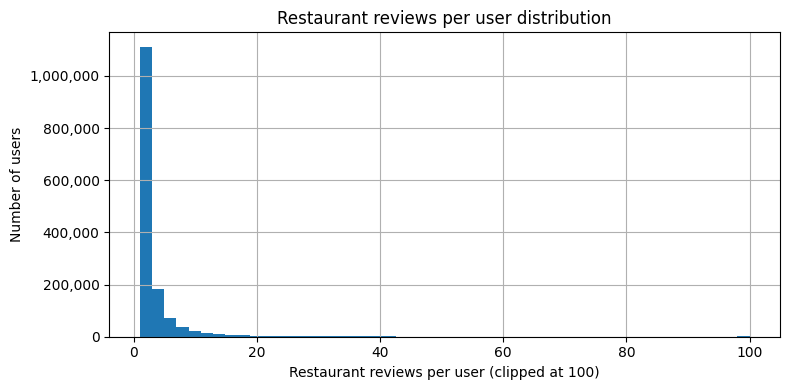

In [12]:
# Reviews per user histogram
fig, ax = plt.subplots(figsize=(8, 4))
reviews_per_user.clip(upper=100).hist(bins=50, ax=ax)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("Restaurant reviews per user (clipped at 100)")
ax.set_ylabel("Number of users")
ax.set_title("Restaurant reviews per user distribution")
plt.tight_layout()
plt.show()

In [13]:
# Reviews per business distribution
reviews_per_business = yelp_restaurant_reviews_df.groupby("business_id").size()
print("Reviews per business (from review data):")
print(reviews_per_business.describe())
print(f"\nBusinesses with >= 5 reviews:  {(reviews_per_business >= 5).sum():,}")
print(f"Businesses with >= 10 reviews: {(reviews_per_business >= 10).sum():,}")

Reviews per business (from review data):
count    64616.000000
mean        79.332364
std        178.002816
min          5.000000
25%         12.000000
50%         29.000000
75%         78.000000
max       7673.000000
dtype: float64

Businesses with >= 5 reviews:  64,616
Businesses with >= 10 reviews: 52,531


## Users

In [14]:
# Load user data
yelp_users_data_path = "../Yelp JSON/yelp_dataset/yelp_academic_dataset_user.json"

with open(yelp_users_data_path, "r") as f:
    yelp_users = [json.loads(line) for line in f]

yelp_users_df = pd.DataFrame(yelp_users)
print(f"Total users: {len(yelp_users_df):,}")
yelp_users_df.head()

Total users: 1,987,897


,user_id,name,review_count,yelping_since,useful,funny,cool,elite,friends,fans,...,compliment_more,compliment_profile,compliment_cute,compliment_list,compliment_note,compliment_plain,compliment_cool,compliment_funny,compliment_writer,compliment_photos
0,qVc8ODYU5SZjKXVBgXdI7w,Walker,585,2007-01-25 16:47:26,7217,1259,5994,2007,"NSCy54eWehBJyZdG2iE84w, pe42u7DcCH2QmI81NX-8qA...",267,...,65,55,56,18,232,844,467,467,239,180
1,j14WgRoU_-2ZE1aw1dXrJg,Daniel,4333,2009-01-25 04:35:42,43091,13066,27281,"2009,2010,2011,2012,2013,2014,2015,2016,2017,2...","ueRPE0CX75ePGMqOFVj6IQ, 52oH4DrRvzzl8wh5UXyU0A...",3138,...,264,184,157,251,1847,7054,3131,3131,1521,1946
2,2WnXYQFK0hXEoTxPtV2zvg,Steph,665,2008-07-25 10:41:00,2086,1010,1003,"2009,2010,2011,2012,2013","LuO3Bn4f3rlhyHIaNfTlnA, j9B4XdHUhDfTKVecyWQgyA...",52,...,13,10,17,3,66,96,119,119,35,18
3,SZDeASXq7o05mMNLshsdIA,Gwen,224,2005-11-29 04:38:33,512,330,299,"2009,2010,2011","enx1vVPnfdNUdPho6PH_wg, 4wOcvMLtU6a9Lslggq74Vg...",28,...,4,1,6,2,12,16,26,26,10,9
4,hA5lMy-EnncsH4JoR-hFGQ,Karen,79,2007-01-05 19:40:59,29,15,7,,"PBK4q9KEEBHhFvSXCUirIw, 3FWPpM7KU1gXeOM_ZbYMbA...",1,...,1,0,0,0,1,1,0,0,0,0


In [15]:
# Filter by users who appear in restaurant reviews
review_user_ids = set(yelp_restaurant_reviews_df["user_id"])
yelp_users_filtered_df = yelp_users_df[yelp_users_df["user_id"].isin(review_user_ids)].copy()
print(f"Total users in dataset:        {len(yelp_users_df):,}")
print(f"Users with restaurant reviews: {len(yelp_users_filtered_df):,}")

Total users in dataset:        1,987,897
Users with restaurant reviews: 1,505,666


In [16]:
# Null rates for potential user tower features to pick
user_tower_features = [
    "review_count", "average_stars", "useful", "funny", "cool",
    "fans", "elite",
    "compliment_hot", "compliment_more", "compliment_profile",
    "compliment_cute", "compliment_list", "compliment_note",
    "compliment_plain", "compliment_cool", "compliment_funny",
    "compliment_writer", "compliment_photos"
]
existing = [f for f in user_tower_features if f in yelp_users_filtered_df.columns]
null_rates = yelp_users_filtered_df[existing].isnull().mean().sort_values(ascending=False) * 100
print("Null rate (%) for user tower features:")
print(null_rates.to_string())

Null rate (%) for user tower features:
review_count          0.0
average_stars         0.0
compliment_writer     0.0
compliment_funny      0.0
compliment_cool       0.0
compliment_plain      0.0
compliment_note       0.0
compliment_list       0.0
compliment_cute       0.0
compliment_profile    0.0
compliment_more       0.0
compliment_hot        0.0
elite                 0.0
fans                  0.0
cool                  0.0
funny                 0.0
useful                0.0
compliment_photos     0.0


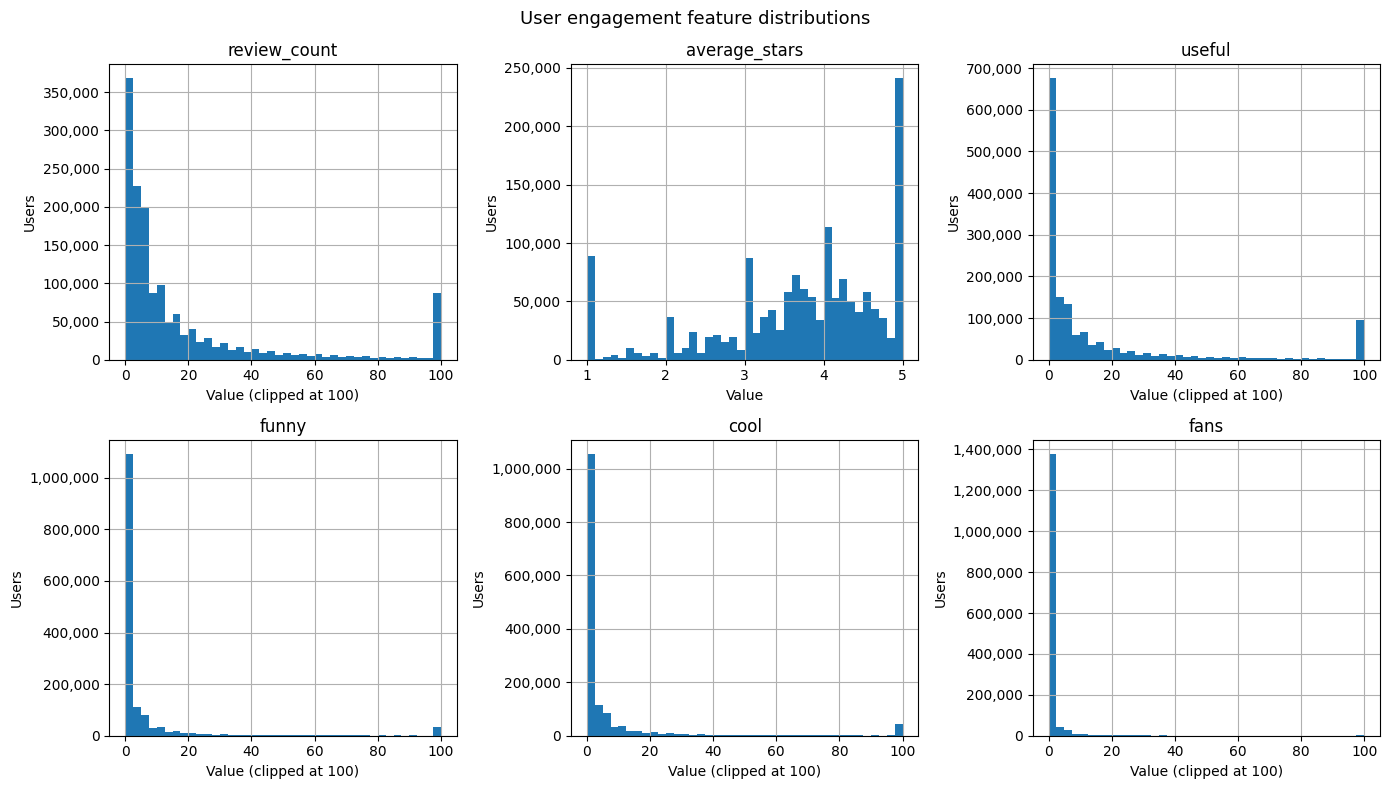

In [17]:
# Key engagement features distribution
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
engagement_features = ["review_count", "average_stars", "useful", "funny", "cool", "fans"]
clip_values = [100, None, 100, 100, 100, 100]

for ax, feat, clip in zip(axes.flat, engagement_features, clip_values):
    col = yelp_users_filtered_df[feat].dropna()
    if clip:
        col = col.clip(upper=clip)
    col.hist(bins=40, ax=ax)
    ax.set_title(feat)
    ax.set_xlabel("Value" + (f" (clipped at {clip})" if clip else ""))
    ax.set_ylabel("Users")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("User engagement feature distributions", fontsize=13)
plt.tight_layout()
plt.show()